## Import Packages and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.mixture import GaussianMixture

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/My Drive/DSA3101/BankChurners.csv'
df = pd.read_csv(filepath)

Mounted at /content/drive


In [3]:
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


# Data Processing

### Encoding Categorical Data

In [4]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
df_subset = df[['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count',
                'Months_Inactive_12_mon','Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal','Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']]

In [6]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


In [7]:
for col in df_subset[['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']]:
    print(df_subset[col].unique())

['M' 'F']
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
['Married' 'Single' 'Unknown' 'Divorced']
['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
['Blue' 'Gold' 'Silver' 'Platinum']


In [8]:
df_subset = df_subset.copy()

# Using Label Encoding for Gender & Martial_Status
label_encoder = LabelEncoder()

df_subset['Gender'] = label_encoder.fit_transform(df_subset['Gender'])
df_subset['Marital_Status'] = label_encoder.fit_transform(df_subset['Marital_Status'])

In [9]:
df_subset = df_subset.copy()

# Define ordered categories
education_order = ['Unknown', 'Uneducated', 'High School', 'College', 'Graduate', 'Post-Graduate', 'Doctorate']
income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']
card_order = ["Blue", "Silver", "Gold", "Platinum"]

# Ensure the columns are strings
df_subset['Education_Level'] = df_subset['Education_Level'].astype(str)
df_subset['Income_Category'] = df_subset['Income_Category'].astype(str)
df_subset['Card_Category'] = df_subset['Card_Category'].astype(str)

In [10]:
# Apply Ordinal Encoding
ordinal_encoder_education = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Education_Level'] = ordinal_encoder_education.fit_transform(df_subset[['Education_Level']]).astype(float)

ordinal_encoder_income = OrdinalEncoder(categories=[income_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Income_Category'] = ordinal_encoder_income.fit_transform(df_subset[['Income_Category']]).astype(float)

ordinal_encoder_card = OrdinalEncoder(categories=[card_order], handle_unknown='use_encoded_value', unknown_value=np.nan)
df_subset['Card_Category'] = ordinal_encoder_card.fit_transform(df_subset[['Card_Category']]).astype(float)

In [11]:
df_subset.dtypes

,0
Customer_Age,int64
Gender,int64
Dependent_count,int64
Education_Level,float64
Marital_Status,int64
Income_Category,float64
Card_Category,float64
Months_on_book,int64
Total_Relationship_Count,int64
Months_Inactive_12_mon,int64


In [12]:
kmeans_data  = df_subset.copy()
kmeans_data_clustered = df_subset.copy()
gmm_data  = df_subset.copy()
gmm_data_clustered = df_subset.copy()
hc_data  = df_subset.copy()
hc_data_clustered = df_subset.copy()
dbscan_data  = df_subset.copy()
dbscan_data_clustered = df_subset.copy()
df_cleaned = df_subset.copy()

### Viewing data

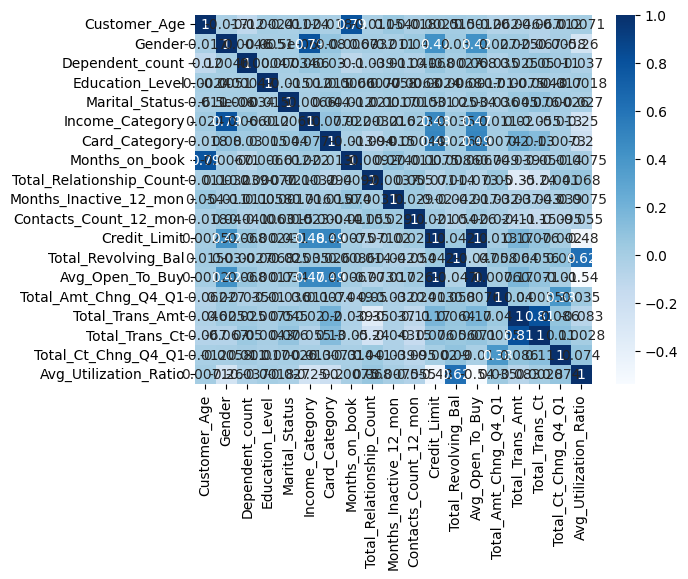

In [13]:
corr = df_subset.corr()
sns.heatmap(corr, cmap="Blues", annot=True)
sns.set_theme(rc={'figure.figsize':(10,10)})

### Feature Scaling

We will now apply feature scaling to

In [14]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)

In [15]:
df_scaled = pd.DataFrame(df_scaled)

df_scaled.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,-0.165406,1.059956,0.503368,-0.354022,-0.628128,0.620039,-0.250587,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,-0.959707,-0.973895,3.834003,-0.775882
1,0.333570,-0.943436,2.043199,0.822218,0.727306,-0.736292,-0.250587,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,-0.916433,-1.357340,12.608573,-0.616276
2,0.583058,1.059956,0.503368,0.822218,-0.628128,1.298204,-0.250587,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,-0.740982,-1.911206,6.807864,-0.997155
3,-0.789126,-0.943436,1.273283,-0.354022,2.082739,-0.736292,-0.250587,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,-0.951758,-1.911206,6.807864,1.759686
4,-0.789126,1.059956,0.503368,-0.942142,-0.628128,0.620039,-0.250587,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,-1.056263,-1.570365,7.509325,-0.997155


# Hierarchical Clustering

## Modelling

### Plotting Dendrogram

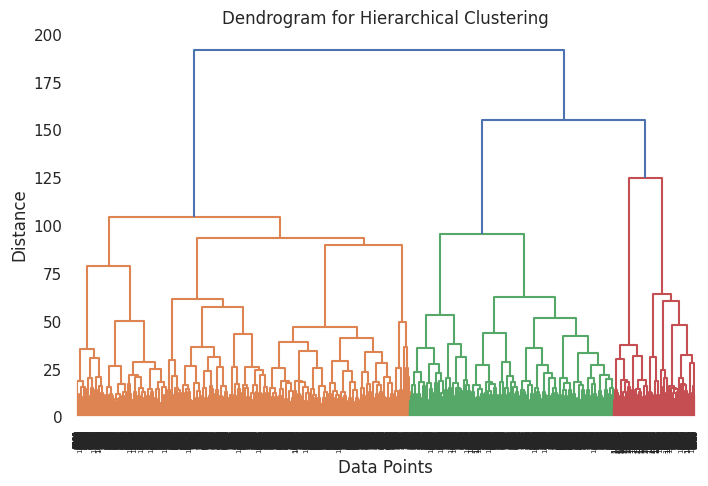

In [16]:
# Create the linkage matrix
linkage_matrix = sch.linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(8, 5))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Running Hierarchical Clustering

In [17]:
# We will use 5 clusters as suggested by the Dendrogram
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
hc_clustered = hc.fit_predict(df_scaled)

In [18]:
hc_segmented = hc_clustered.copy()

hc_data_clustered['Cluster'] = hc_segmented

## Cluster statistics

In [31]:
summary_stats = hc_data.groupby('Cluster').agg(['mean', 'median', 'std'])
print(summary_stats)

        Customer_Age                     Gender                   \
                mean median       std      mean median       std   
Cluster                                                            
0          46.535854   47.0  6.639738  0.990699    1.0  0.096006   
1          41.383543   42.0  8.030251  0.155275    0.0  0.362287   
2          48.370071   48.0  8.333446  0.112487    0.0  0.316005   
3          45.102837   46.0  8.440160  0.508865    1.0  0.500365   
4          45.481095   45.0  6.962739  0.653194    1.0  0.476264   

        Dependent_count                  Education_Level  ... Total_Trans_Amt  \
                   mean median       std            mean  ...             std   
Cluster                                                   ...                   
0              2.572157    3.0  1.179799        2.615062  ...     1982.665395   
1              2.261447    2.0  1.390298        2.370272  ...     1644.316150   
2              2.172396    2.0  1.324707        2.

## Plotting Clusters Distribution

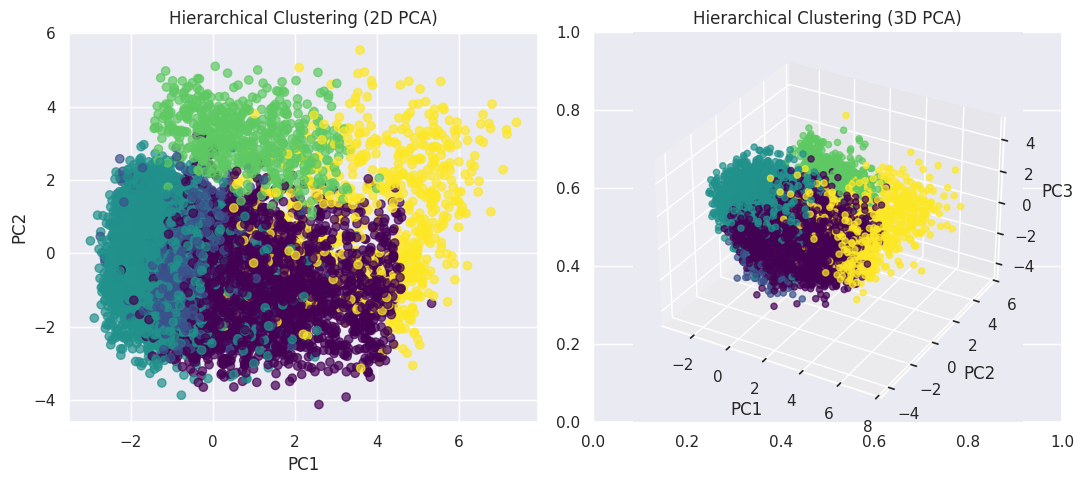

In [19]:
# Reduce dimensions to 2 for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

# Reduce dimensions to 3 for visualization
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={'projection': None})

# 2D Scatter Plot
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=hc_clustered, cmap='viridis', alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Hierarchical Clustering (2D PCA)")
axes[0].grid(True)

# 3D Scatter Plot
ax3d = fig.add_subplot(1, 2, 2, projection='3d')
ax3d.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=hc_clustered, cmap='viridis', alpha=0.7)
ax3d.set_xlabel("PC1")
ax3d.set_ylabel("PC2")
ax3d.set_zlabel("PC3")
ax3d.set_title("Hierarchical Clustering (3D PCA)")

plt.tight_layout()
plt.show()

In [20]:
# Printing number of data points in each cluster
cluster_counts = pd.Series(hc_clustered).value_counts().sort_index()

print("Number of data points in each cluster:")
print(cluster_counts)

Number of data points in each cluster:
0    3333
1    1507
2    3956
3     564
4     767
Name: count, dtype: int64


## Plotting Distrbution within Clusters

### Customer Attributes

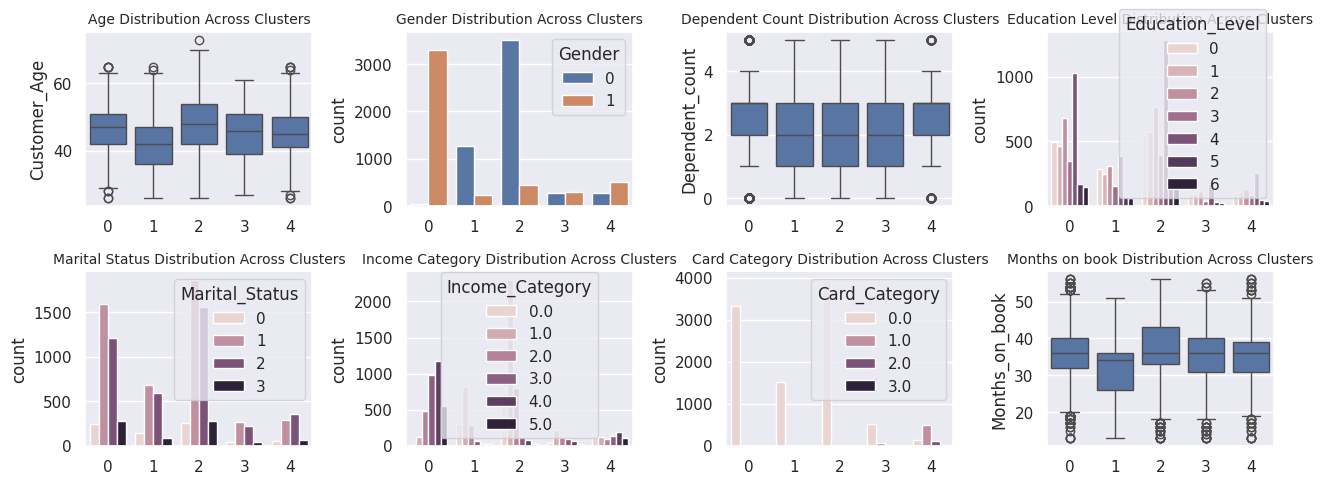

In [21]:
# Create a figure with 2 row and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(13, 5))

# Plot Age Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Customer_Age'], ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution Across Clusters", fontsize=10)

# Plot Gender Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Gender'], ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution Across Clusters", fontsize=10)

# Plot Dependent Count Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Dependent_count'], ax=axes[0, 2])
axes[0, 2].set_title("Dependent Count Distribution Across Clusters", fontsize=10)

# Plot Education Level Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Education_Level'], ax=axes[0 , 3])
axes[0, 3].set_title("Education Level Distribution Across Clusters", fontsize=10)

# Plot Marital Status Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Marital_Status'], ax=axes[1, 0])
axes[1, 0].set_title("Marital Status Distribution Across Clusters", fontsize=10)

# Plot Income Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Income_Category'], ax=axes[1, 1])
axes[1, 1].set_title("Income Category Distribution Across Clusters", fontsize=10)

# Plot Card Category Distribution
sns.countplot(x=hc_clustered, hue=hc_data['Card_Category'], ax=axes[1, 2])
axes[1, 2].set_title("Card Category Distribution Across Clusters", fontsize=10)

# Plot Months_on_book Distribution
sns.boxplot(x=hc_clustered, y=hc_data['Months_on_book'], ax=axes[1, 3])
axes[1, 3].set_title("Months on book Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [22]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Customer_Age', 'Gender', 'Dependent_count',	'Education_Level',	'Marital_Status',	'Income_Category',	'Card_Category',	'Months_on_book']]

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
Cluster,,,,,,,,
0,46.535854,0.990699,2.572157,2.615062,1.458746,3.461746,0.001500,36.193819
1,41.383543,0.155275,2.261447,2.370272,1.412077,1.173192,0.000000,31.319841
2,48.370071,0.112487,2.172396,2.672649,1.467897,1.185288,0.001769,37.749747
3,45.102837,0.508865,2.195035,2.464539,1.452128,2.012411,0.097518,34.976950
4,45.481095,0.653194,2.538462,2.736636,1.569752,2.597132,1.016949,35.135593


### Transactional Data

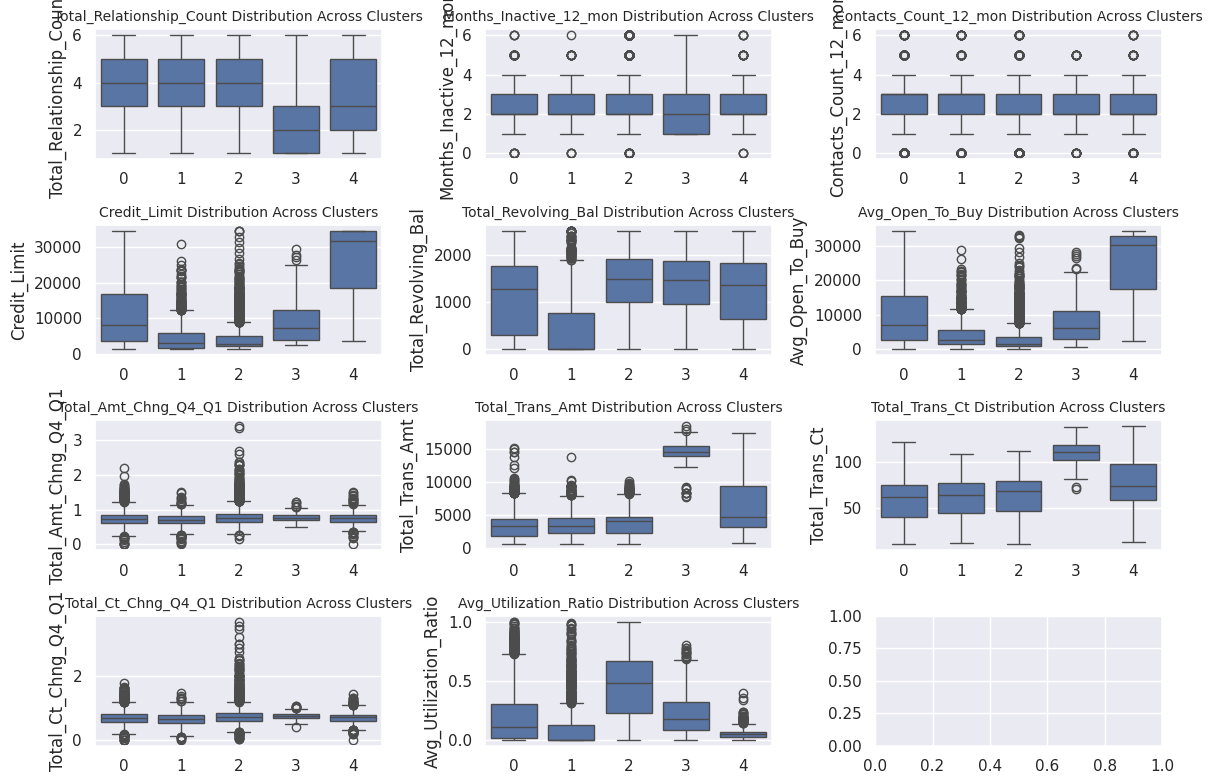

In [23]:
# Create a figure with 2 row and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 8))

sns.boxplot(x=hc_clustered, y=hc_data['Total_Relationship_Count'], ax=axes[0, 0])
axes[0, 0].set_title("Total_Relationship_Count Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Months_Inactive_12_mon'], ax=axes[0, 1])
axes[0, 1].set_title("Months_Inactive_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Contacts_Count_12_mon'], ax=axes[0, 2])
axes[0, 2].set_title("Contacts_Count_12_mon Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Credit_Limit'], ax=axes[1, 0])
axes[1, 0].set_title("Credit_Limit Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Revolving_Bal'], ax=axes[1, 1])
axes[1, 1].set_title("Total_Revolving_Bal Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Open_To_Buy'], ax=axes[1, 2])
axes[1, 2].set_title("Avg_Open_To_Buy Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Amt_Chng_Q4_Q1'], ax=axes[2, 0])
axes[2, 0].set_title("Total_Amt_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Amt'], ax=axes[2, 1])
axes[2, 1].set_title("Total_Trans_Amt Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Trans_Ct'], ax=axes[2, 2])
axes[2, 2].set_title("Total_Trans_Ct Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Total_Ct_Chng_Q4_Q1'], ax=axes[3, 0])
axes[3, 0].set_title("Total_Ct_Chng_Q4_Q1 Distribution Across Clusters", fontsize=10)

sns.boxplot(x=hc_clustered, y=hc_data['Avg_Utilization_Ratio'], ax=axes[3, 1])
axes[3, 1].set_title("Avg_Utilization_Ratio Distribution Across Clusters", fontsize=10)

# Adjust the layout to avoid overlapping
plt.tight_layout()
plt.show()

In [24]:
# Using the ‘groupby’ method to group the cluster value and inspect the mean value of each of the attributes in the dataset using the ‘mean’ method.
hc_data_clustered.groupby('Cluster').mean()[['Total_Relationship_Count', 'Credit_Limit', 'Avg_Open_To_Buy',	'Total_Trans_Amt',	'Total_Trans_Ct',	'Avg_Utilization_Ratio']]

,Total_Relationship_Count,Credit_Limit,Avg_Open_To_Buy,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster,,,,,,
0,3.942694,11443.730123,10279.645215,3435.159016,58.661566,0.204265
1,3.885202,4546.830325,4148.862177,3523.972794,61.079628,0.098979
2,3.981547,4237.820854,2820.638094,3604.635996,62.870829,0.452448
3,2.312057,8867.157801,7509.959220,14631.301418,109.897163,0.220819
4,3.336375,26930.734029,25725.584094,6946.774446,76.348110,0.051425


## Cluster Analysis

*   **Cluster 0: Mid-High Income Males with Dependents, Strong Banking Relationship**
      - Likely financially stable men managing family expenses with good banking engagement and responsible credit use.
*   **Cluster 1: Young, Low-Income Females with Shortest Tenure & Low Credit**
      - Newer bank customers with limited financial history, lower credit access, and cautious spending.
*   **Cluster 2: Older, Low-Income Females with Strong Banking Relationship & High Utilisation**
      - Long-term customers with lower incomes, relying heavily on credit, possibly facing financial constraints.
*  **Cluster 3: Mid-Income Graduates with High Spending & Transactions**
      - Likely financially independent individuals who spend actively but don’t engage deeply with the bank.
*   **Cluster 4: Educated, Single Individuals with High Credit & Low Utilisation**
      - Financially stable, independent, and responsible spenders who manage credit well.




# Customer Behaviour
Investigate:
- How do customer behaviours vary across different segments?
- **Objective**: Analyze patterns in product usage, transaction history, and digital engagement among various customer segments
- **Expected Outcome**: Use insights to recommend targeted marketing approaches for each segment

In [25]:
hc_data['Cluster'] = hc_clustered

In [26]:
# splitting original df according to clusters
c0 = hc_data[hc_data['Cluster'] == 0]
c1 = hc_data[hc_data['Cluster'] == 1]
c2 = hc_data[hc_data['Cluster'] == 2]
c3 = hc_data[hc_data['Cluster'] == 3]
c4 = hc_data[hc_data['Cluster'] == 4]

Some of the useful features for analysing customer behaviours  
- Months on book: period of relationship with bank;
- Attrition Flag: whether customer still using the bank's services
- Dependenct_counts: how many individuals are fianancially dependent on the customer
- Total Relationship Count: number of products held by the customer
- Months inactive: no. of months inactive in the past 12 months
- Contacts count: number of contacts with the bank in the past 12 months
- Credit Limit: credit card limit
- Avg open to buy: avg available budget/credit for future purchases
- Change to transaction amt Q4 to Q1: ratio change in transaction amt
- credit utilization ratio: how much credit is used

## Transaction History Analysis

To analyse the transaction history, examine the following columns  
- Total_Amt_Chng_Q4_Q1
- Total_Trans_Amt
- Total_Trans_Ct
- Total_Ct_Chng_Q4_Q1

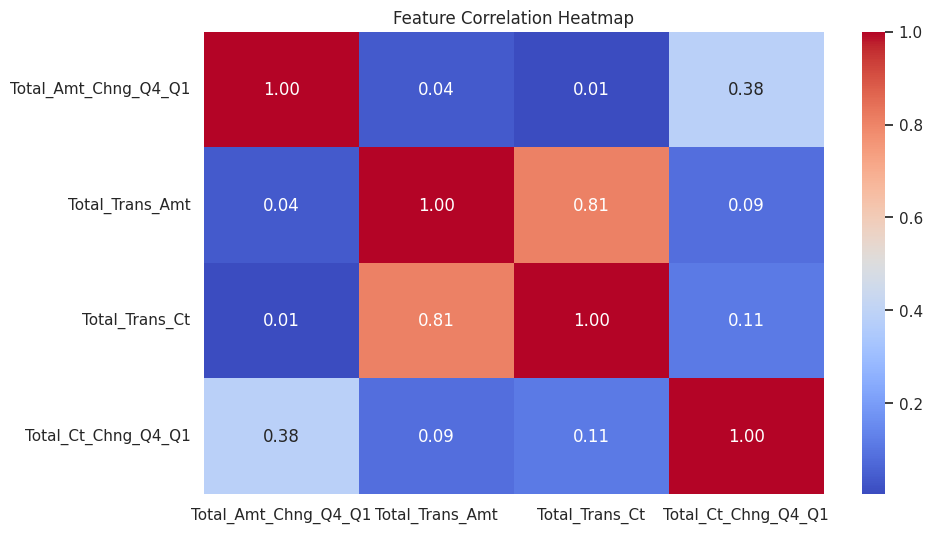

In [37]:
selected_columns = ['Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1']
plt.figure(figsize=(10, 6))
sns.heatmap(hc_data[selected_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

A positive correlation is observe between total transaction count and total transaction amount. This trend is quite intuitive.  
There isn't any note-worthy trend between other features related to transactions.

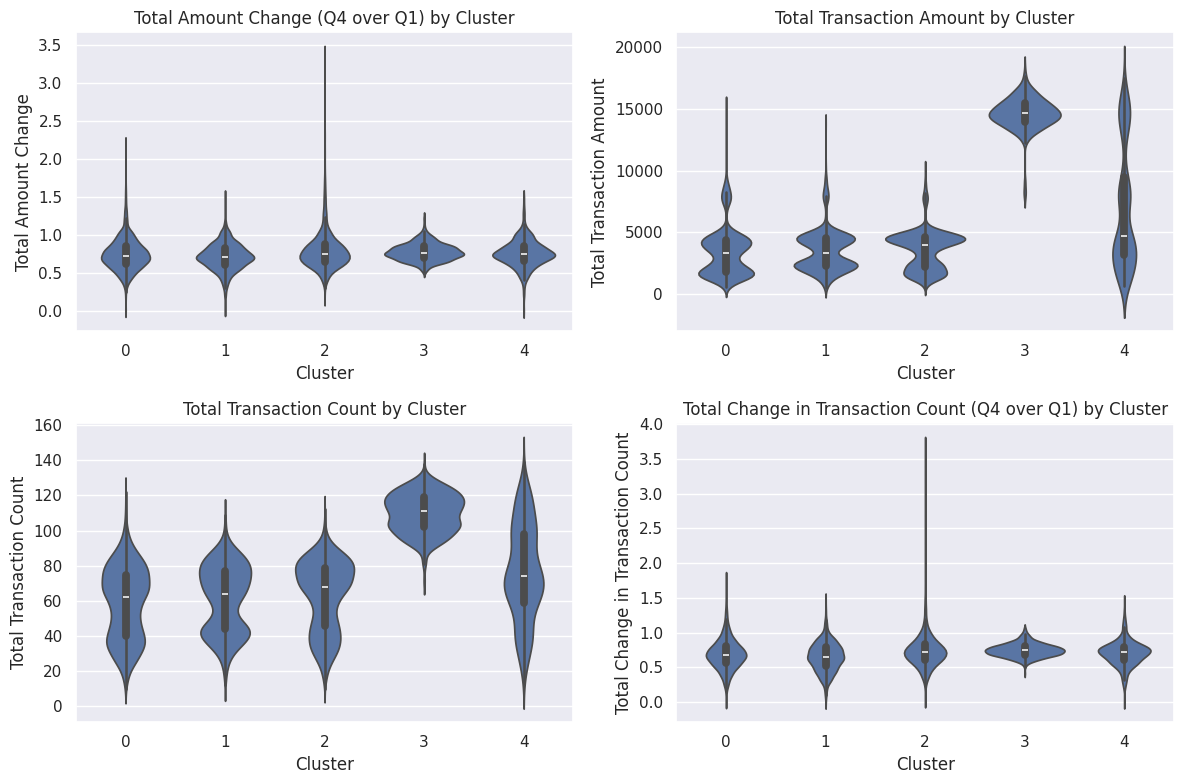

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Total_Amt_Chng_Q4_Q1', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Total Amount Change (Q4 over Q1) by Cluster')
axes[0, 0].set_ylabel('Total Amount Change')

sns.violinplot(x='Cluster', y='Total_Trans_Amt', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Total Transaction Amount by Cluster')
axes[0, 1].set_ylabel('Total Transaction Amount')

sns.violinplot(x='Cluster', y='Total_Trans_Ct', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Total Transaction Count by Cluster')
axes[1, 0].set_ylabel('Total Transaction Count')

sns.violinplot(x='Cluster', y='Total_Ct_Chng_Q4_Q1', data=hc_data, ax=axes[1, 1])
axes[1, 1].set_title('Total Change in Transaction Count (Q4 over Q1) by Cluster')
axes[1, 1].set_ylabel('Total Change in Transaction Count')

plt.tight_layout()

plt.show()

Summary
- Total Amount/Count Change (Q4 over Q1): All clusters have similar mean. The **variance in cluster 3 is the smallest** (both features), suggesting a constant spending pattern with little seasonal changes. They are spending at a predictable level. This might be a sign of irresponsiveness to promotion offers and campaigns. The validity of this hypothesis needs further investigation.  
- In contrast, **cluster 0 and 2 has higher variance** in total transaction amount change. Especially **cluster 2, with significantly higher variance in both features**.This shows that this group of customers exhibits high fluctuations in their spending behaviour.
- Cluster 4 is has the greatest variance in total transaction count and total transaction amount.
Next we investigate the correlation between these transaction features.

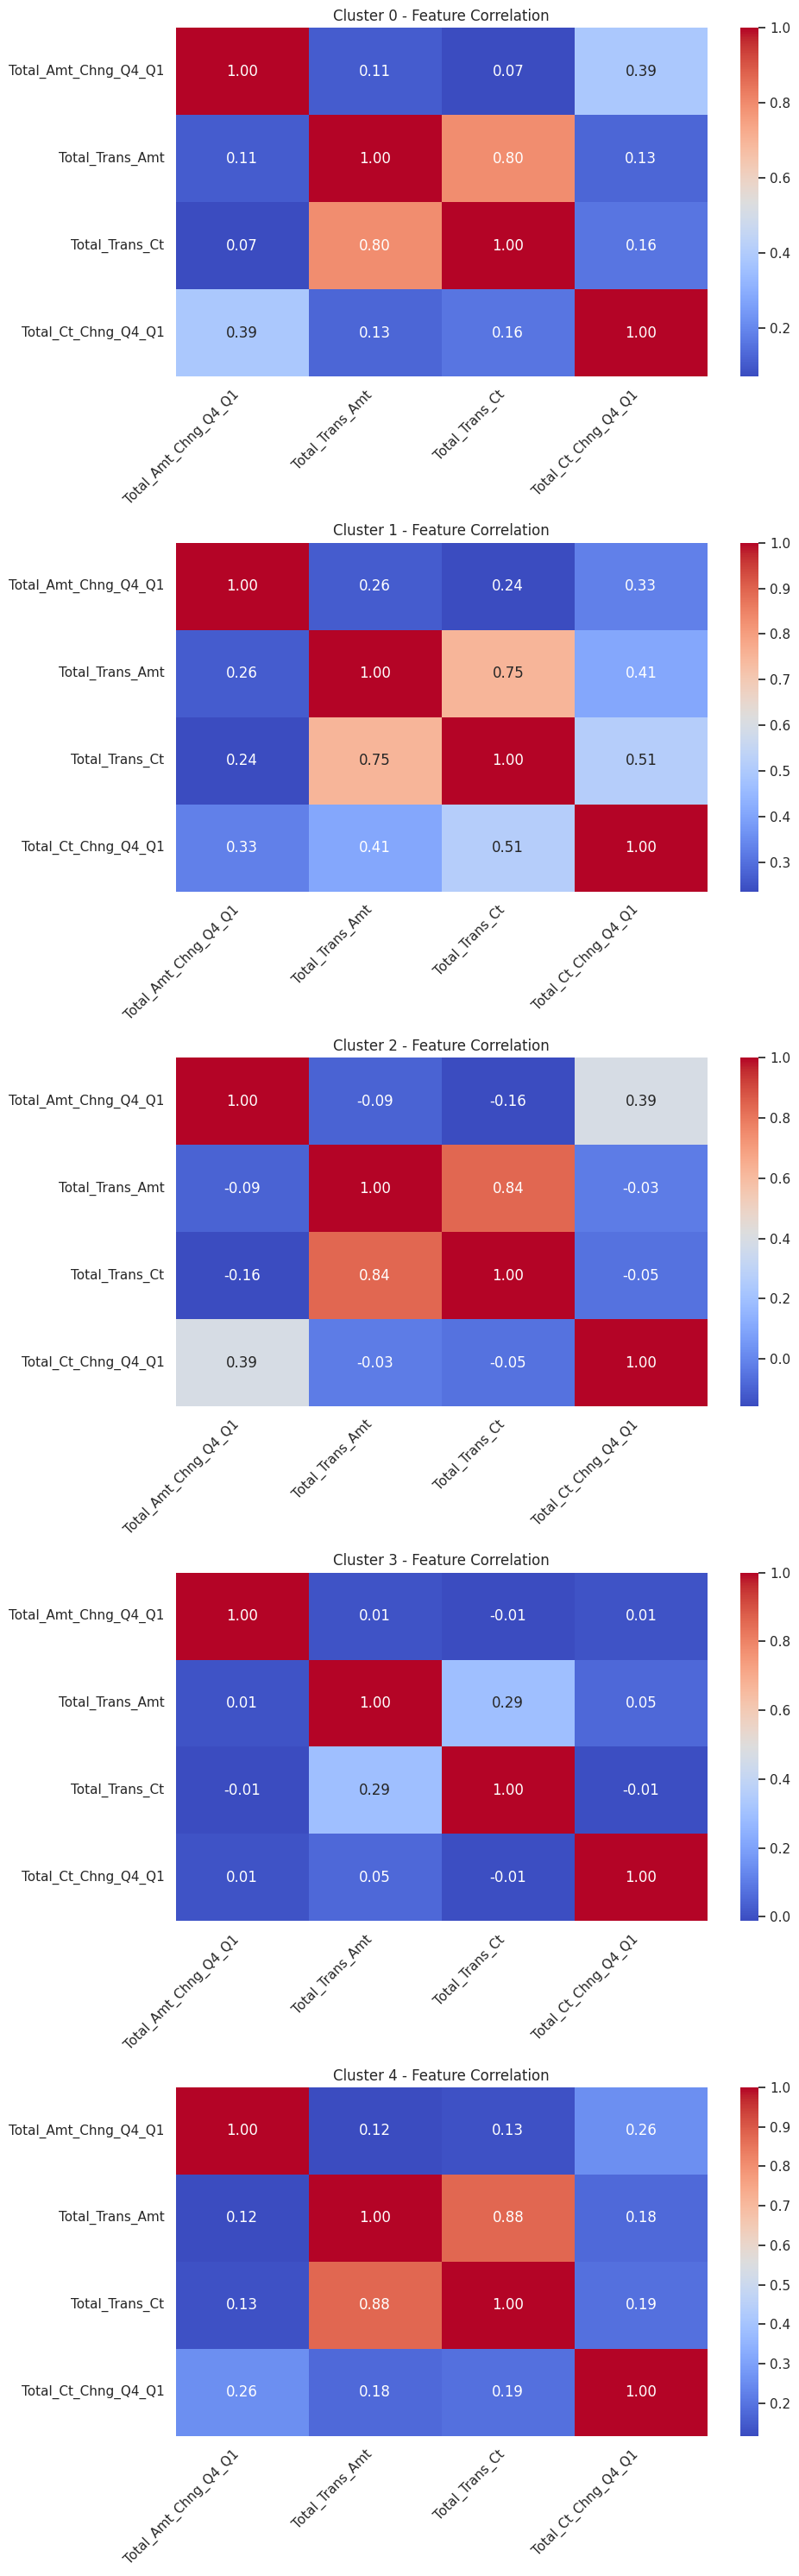

In [38]:
num_clusters = 5
fig, axes = plt.subplots(num_clusters, 1, figsize=(10, 6 * num_clusters))

# Plot a heatmap for each cluster
for i in range(num_clusters):
    # Filter the data for the current cluster
    cluster_data = hc_data[hc_data['Cluster'] == i][selected_columns]

    # Calculate the correlation matrix for the current cluster
    corr_matrix = cluster_data.corr()

    # Plot the heatmap for the current cluster
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[i], cbar=True)
    axes[i].set_title(f'Cluster {i} - Feature Correlation')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

- Further Analysis within the clusters revealed that the strong positive correlation between **total transaction amount** and **total transaction count** holds across clusters, with **the exception of cluster 3** where there is a weak positive correlation ($r = 0.29$);  
- **Cluster 3** has the highest total transaction amount and total transaction count. Combined with previous finding that this groups has the smallest variance in total amount(and count) change Q4 over Q1, this suggests that their spending behaviour is stable and routined. Meanwhile, they might be engaged in **frequent, consistent low cost purchases**. Hence, despite the high transaction count, the total transaction amount might not increase significantly.
- This might suggest that Cluster 3 is **not likely to engage in large amount of transactions**, depite their total high spending.
- **Cluster 4**, having a higher variance in total transaction amount (and count), might suggest that this cluster contains individuals exhibits more **volatile spending behaviours**.

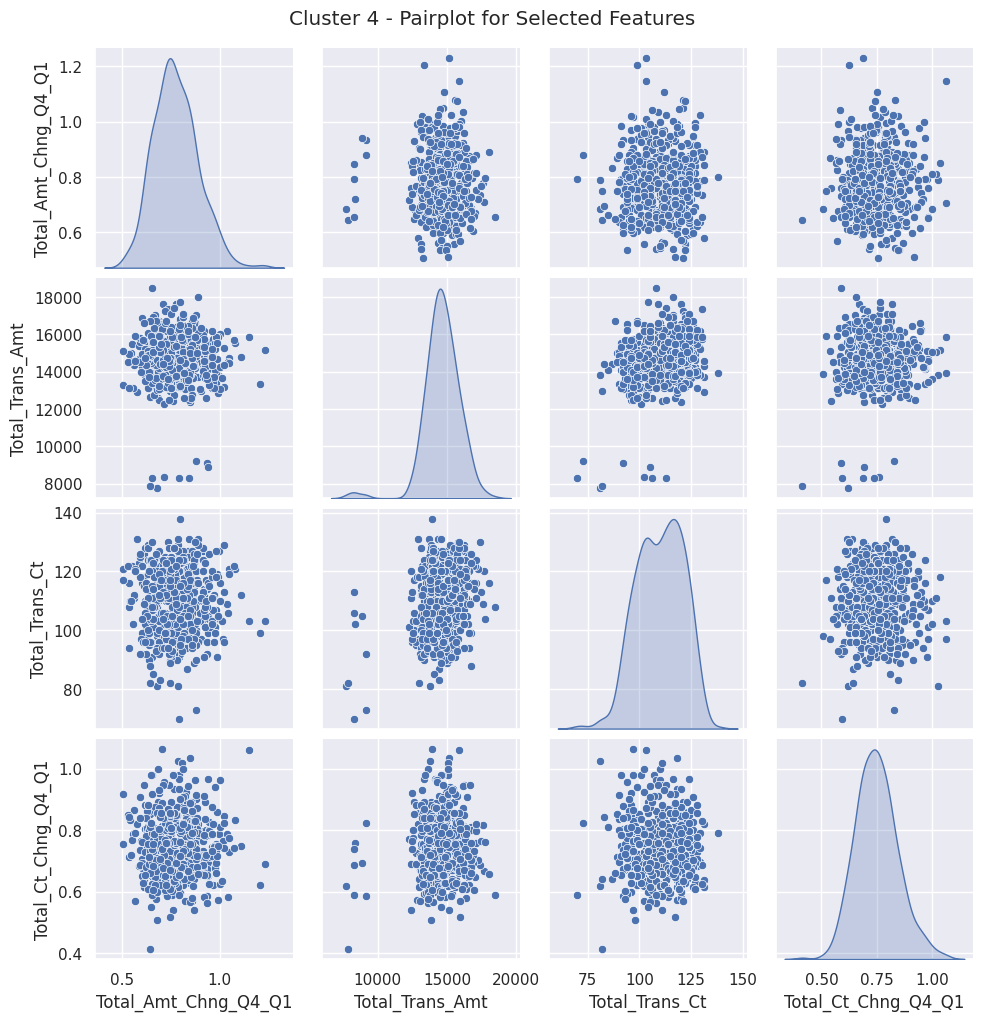

In [41]:
cluster_data = hc_data[hc_data['Cluster'] == 3][selected_columns]

# Plot the pairplot for the current cluster
sns.pairplot(cluster_data, diag_kind='kde')
plt.suptitle(f'Cluster {i} - Pairplot for Selected Features', y=1.02)
plt.show()

## Product Usage


- Total_Relationship_Count

- Total_Revolving_Bal
- Avg_Open_To_Buy
- Avg_Utilization_Ratio

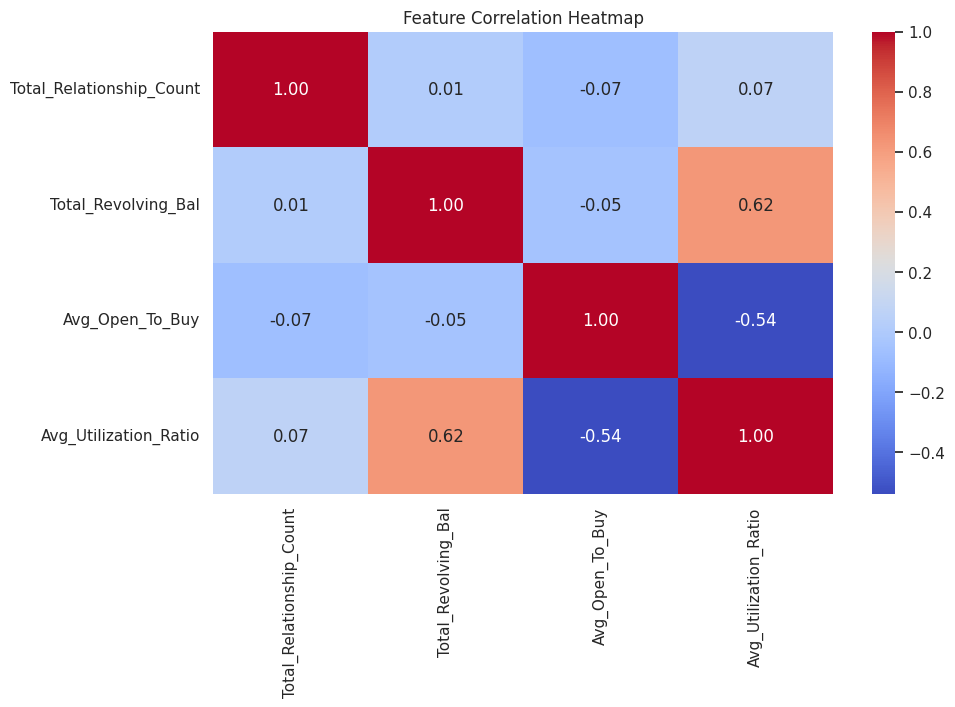

In [42]:
selected_columns = ['Total_Relationship_Count','Total_Revolving_Bal','Avg_Open_To_Buy','Avg_Utilization_Ratio']

plt.figure(figsize=(10, 6))
sns.heatmap(hc_data[selected_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

The overall correlations in these features are not significant.

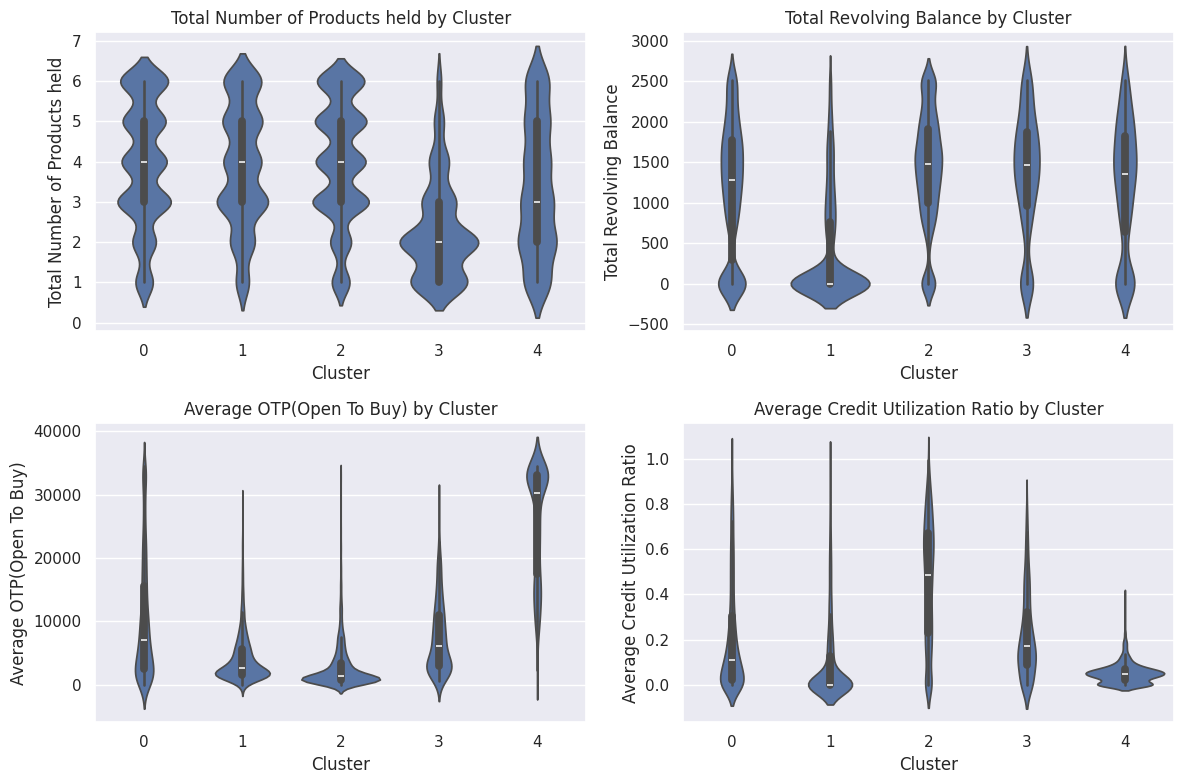

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Total_Relationship_Count', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Total Number of Products held by Cluster')
axes[0, 0].set_ylabel('Total Number of Products held')

sns.violinplot(x='Cluster', y='Total_Revolving_Bal', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Total Revolving Balance by Cluster')
axes[0, 1].set_ylabel('Total Revolving Balance')

sns.violinplot(x='Cluster', y='Avg_Open_To_Buy', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Average OTP(Open To Buy) by Cluster')
axes[1, 0].set_ylabel('Average OTP(Open To Buy)')

sns.violinplot(x='Cluster', y='Avg_Utilization_Ratio', data=hc_data, ax=axes[1, 1])
axes[1, 1].set_title('Average Credit Utilization Ratio by Cluster')
axes[1, 1].set_ylabel('Average Credit Utilization Ratio')

plt.tight_layout()

plt.show()

- Total number of products held: Cluster 0,1 and 2 shows similar patterns with mean of 4, followed by cluster 4 with mean of 3. Cluster 3 has the lowest mean number of products held of only 2. Furthermore, majority of the individuals in cluster 3 hold less than 3 products.
- Total revolving balance: Cluster 1 exhibits unique patters, with majority of individuals having low revolving balance close to the mean value.
- Average open to buy: Cluster 1 and 2 has similar distribution, with majority of individuals having average OTP close to the mean. Cluster 0 and 3 shows similar patterns: average OTP accross the cluster is quite spread-out, with higher mean of average OTP compared to cluster 1 and 2; Cluster 4 shows unique patterns, with siginificanly higher average OTP, and many individuals having average OTP higher than the mean.
- Average credit utilization ratio by cluster: Cluster 0, 1, 3 and 4 have relatively low mean for average credit utilization ratio, with that of cluster 0 and 3 higher than cluster 1 and 4. Cluster 3 and 4 have smaller variance in average credit utilization ratio. Cluster 2 has significantly higher average credit utilization ratio of around $0.5$ compared to the other clusters. The values are very spread-out, with large variance throughout the entire cluster.

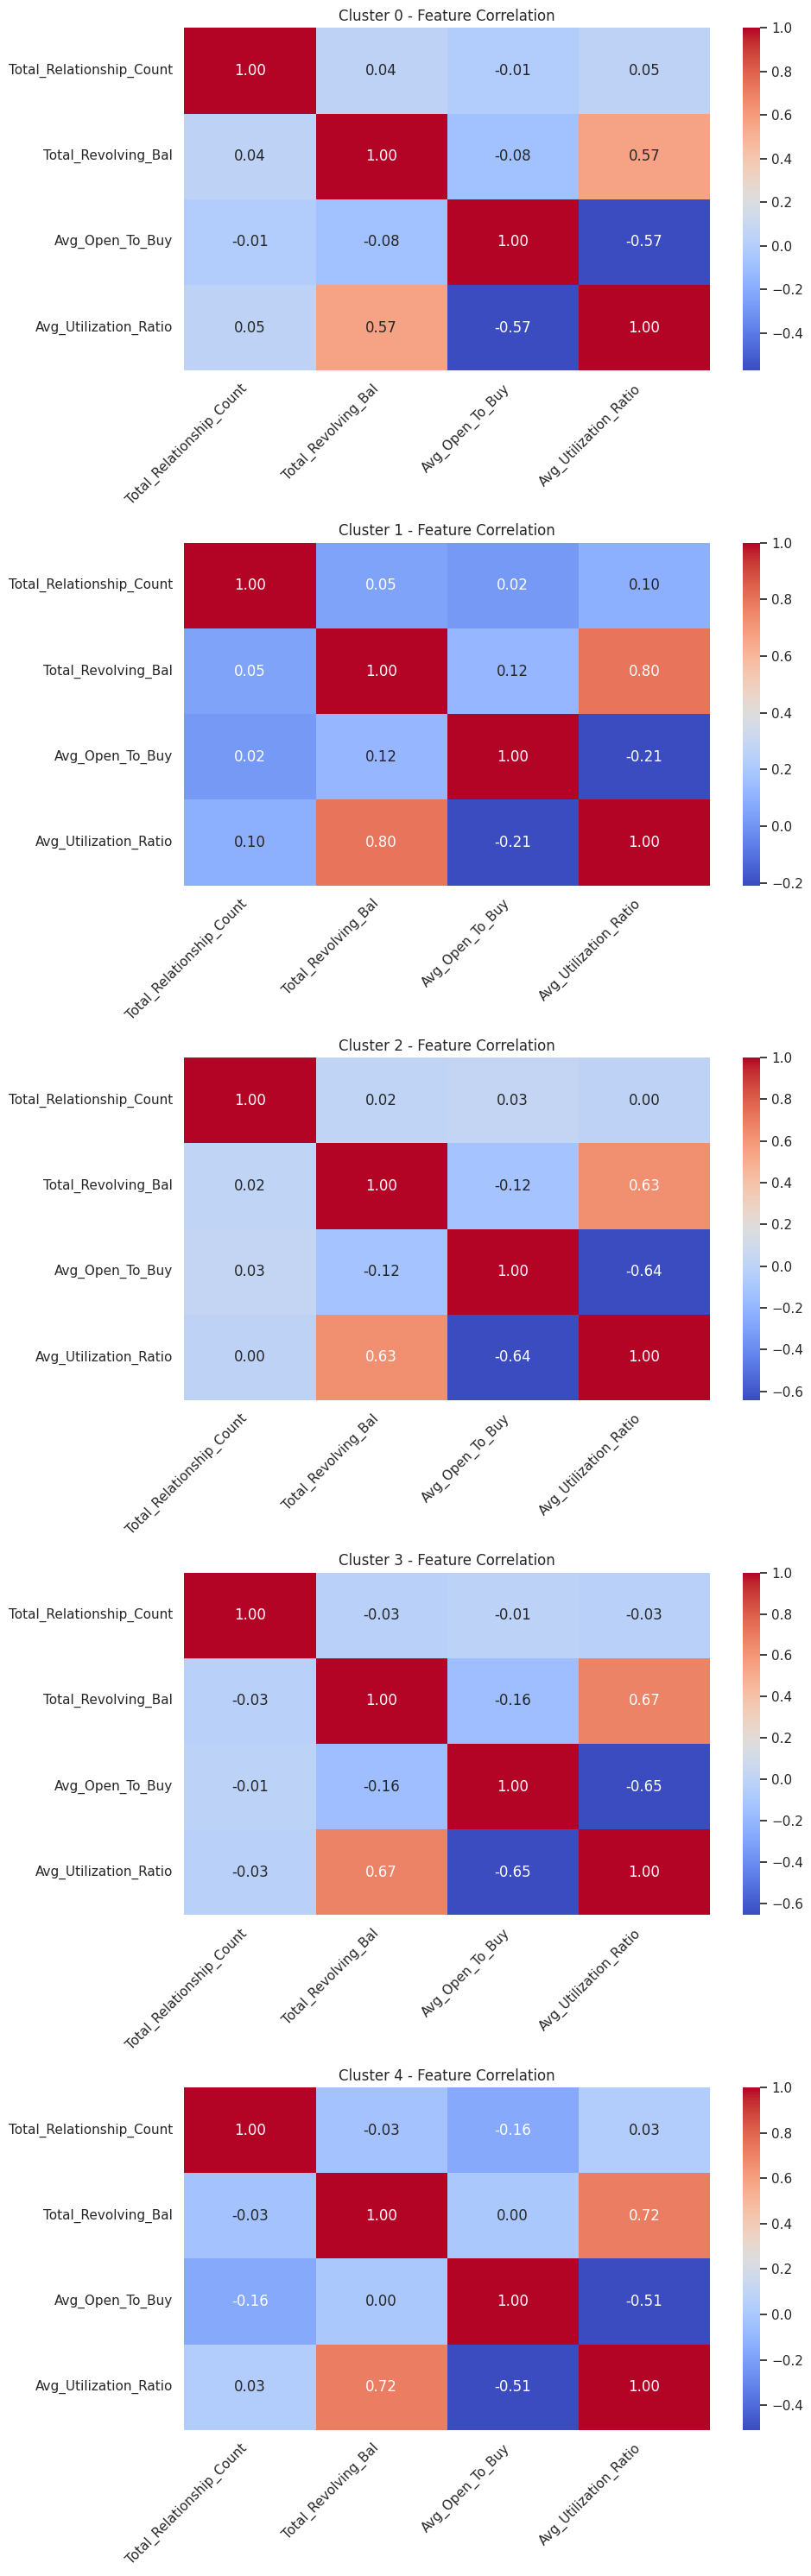

In [43]:
num_clusters = 5
fig, axes = plt.subplots(num_clusters, 1, figsize=(10, 6 * num_clusters))

# Plot a heatmap for each cluster
for i in range(num_clusters):
    # Filter the data for the current cluster
    cluster_data = hc_data[hc_data['Cluster'] == i][selected_columns]

    # Calculate the correlation matrix for the current cluster
    corr_matrix = cluster_data.corr()

    # Plot the heatmap for the current cluster
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[i], cbar=True)
    axes[i].set_title(f'Cluster {i} - Feature Correlation')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

- Cluster 1 and 4: a strong positive correlation between total revolving balance and average utilization ratio is observed. This implies that these customers are consistently using a significant portion of their available credit, indicating they may have higher levels of outstanding debt and could be utilizing more of their credit to finance purchases or maintain liquidity.
- Cluster 0, 2 and 3: moderate positive correlation

- Cluster 2 and 3: a significant negative correlation between average open to buy and average utilization ratio. This might suggest that $1.$ They are conservative spenders that are risk-averse $2.$ They have good financial management. $3. They might have higher income and have financial stability
Cluster 0 and 4 shows moderate negative correlation. Cluster 0 has weak negative correlation.

## (Digital) Engagement

Features to be analysed:  
- Months_on_book
- Months_Inactive_12_mon
- Contacts_Count_12_mon

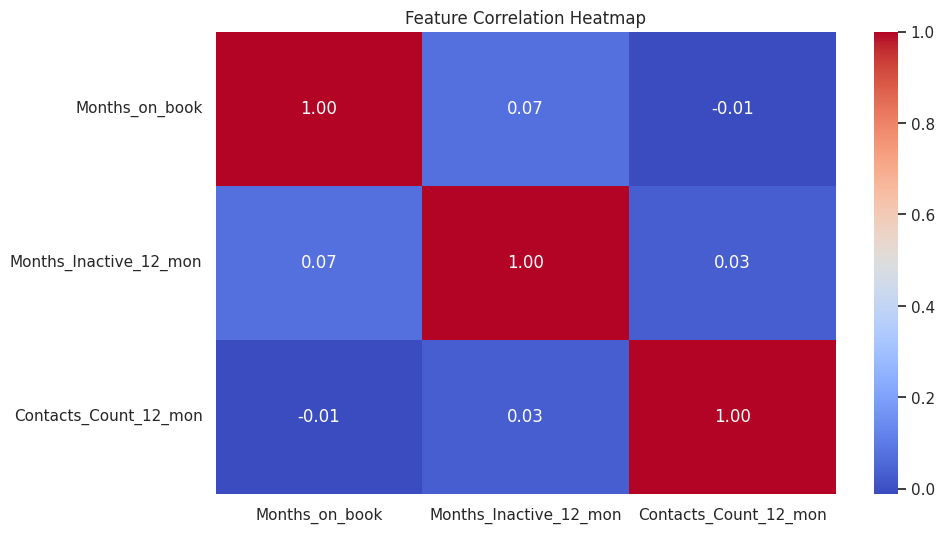

In [44]:
selected_columns = ['Months_on_book','Months_Inactive_12_mon','Contacts_Count_12_mon']

plt.figure(figsize=(10, 6))
sns.heatmap(hc_data[selected_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

No noteworthy correlation between features

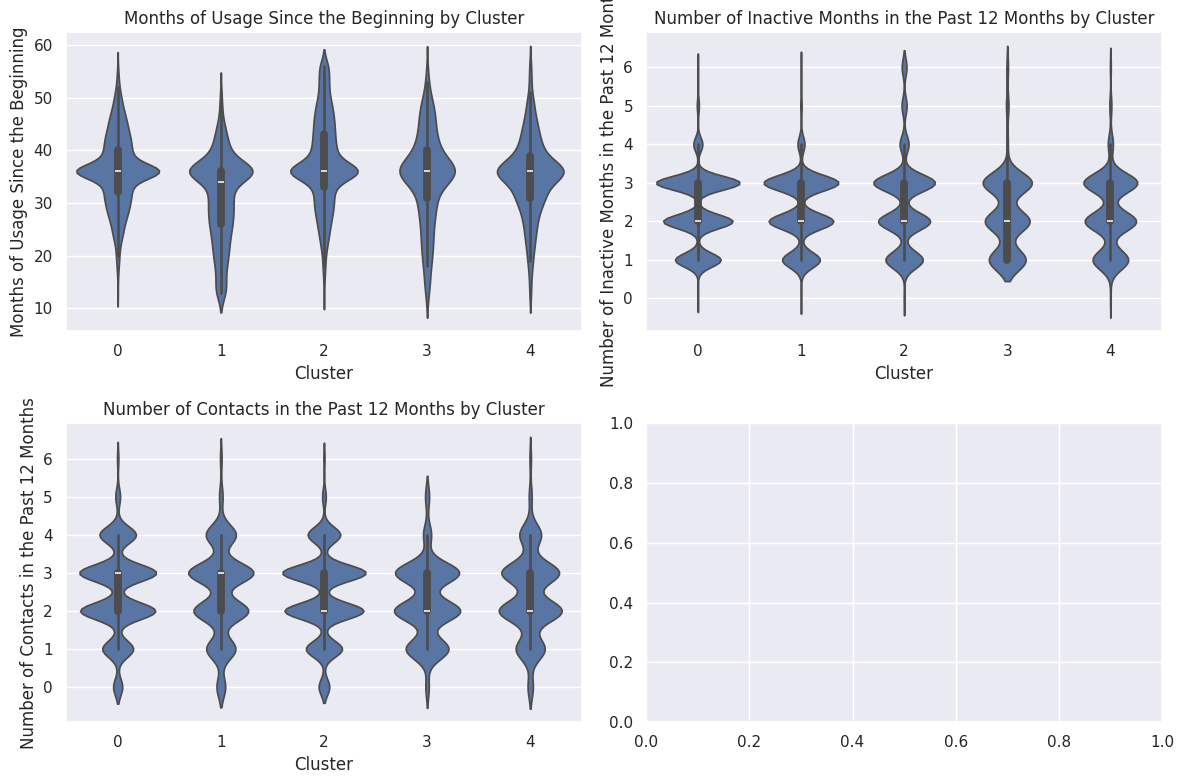

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.violinplot(x='Cluster', y='Months_on_book', data=hc_data, ax=axes[0, 0])
axes[0, 0].set_title('Months of Usage Since the Beginning by Cluster')
axes[0, 0].set_ylabel('Months of Usage Since the Beginning')

sns.violinplot(x='Cluster', y='Months_Inactive_12_mon', data=hc_data, ax=axes[0, 1])
axes[0, 1].set_title('Number of Inactive Months in the Past 12 Months by Cluster')
axes[0, 1].set_ylabel('Number of Inactive Months in the Past 12 Months')

sns.violinplot(x='Cluster', y='Contacts_Count_12_mon', data=hc_data, ax=axes[1, 0])
axes[1, 0].set_title('Number of Contacts in the Past 12 Months by Cluster')
axes[1, 0].set_ylabel('Number of Contacts in the Past 12 Months')

plt.tight_layout()

plt.show()

Only noteworthy trend in this part is that cluster 0 and 1 have higher average number of contacts than cluster 2, 3 and 4. However, the mean number of contacts differ by only 1.

## Other Factors
These are the factors that suggest the profile of customers
- Dependent_count
- Credit_Limit
- Card_Category

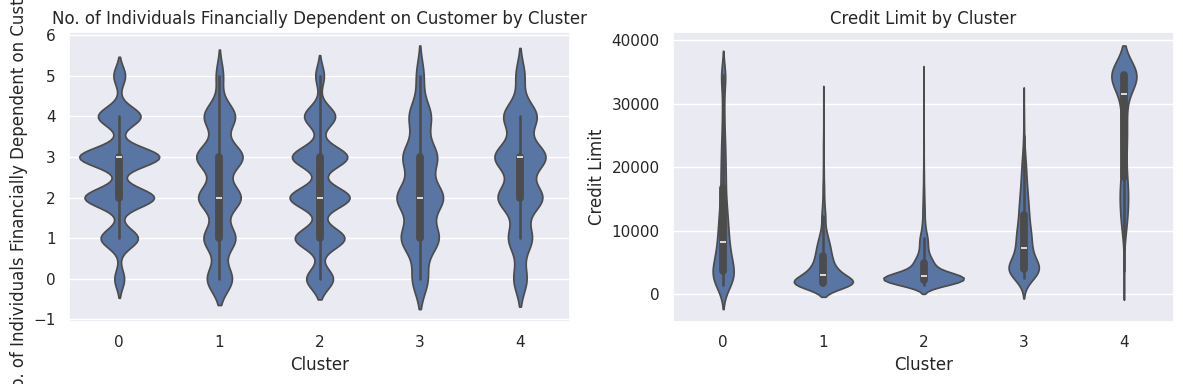

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.violinplot(x='Cluster', y='Dependent_count', data=hc_data, ax=axes[0])
axes[0].set_title('No. of Individuals Financially Dependent on Customer by Cluster')
axes[0].set_ylabel('No. of Individuals Financially Dependent on Customer')

sns.violinplot(x='Cluster', y='Credit_Limit', data=hc_data, ax=axes[1])
axes[1].set_title('Credit Limit by Cluster')
axes[1].set_ylabel('Credit Limit')

plt.tight_layout()

plt.show()

Customer in cluster 0 and 4 have more individuals that are financially dependent on them. Cluster 4 has significantly higher credit limits than the other 4 clusters. Cluster 0 and 3 has higher credit limits compared to cluster 1 and 2.

## Summary

### Cluster 0

- Trends
  - Mid-High Income Males with Dependents
  - higher variance in total transaction amount change
  - more individuals that are financially dependent on them
  - higher credit limits compared to cluster 1 and 2
  - has higher variance in total transaction amount change.This shows that this group of customers exhibits high fluctuations in their spending behaviour, which might indicate varying financial commitments and  irregular expenses (e.g., tuition, family trips, large purchases).
- Engagement Strategy:
  - Offer family-oriented financial products, such as education loans, family insurance plans, and cashback rewards on household spending.
  - Introduce budgeting tools that help manage fluctuating expenses (e.g., salary-based installment plans).
  - Promote loyalty programs for frequent big spenders (e.g., discounts on tuition, family vacations).



### Cluster 1

- Trend:
  - Young, Low-Income Females with Shortest Tenure
  - likely managing early financial independence
  - a strong positive correlation between total revolving balance and average utilization ratio is observed. This implies that these customers are consistently using a significant portion of their available credit, indicating they may have higher levels of outstanding debt and could be utilizing more of their credit to finance purchases or maintain liquidity.They are likely relying on credit frequently and may have limited disposable income.   
  - majority of individuals having low revolving balance close to the mean value.


### Cluster 2
- Trend:
  - Older, Low-Income Females
  - highest variance in total transaction amount change, a significant negative correlation between average open to buy and average utilization ratio. This might suggest that $1.$ They are conservative spenders that are risk-averse  $2.$ They have good financial management.
  - has significantly higher average credit utilization ratio of around  0.5  compared to the other clusters. The values are very spread-out, with large variance throughout the entire cluster. higher variance in total transaction amount change.
  - significantly higher variance in changes in total transaction amount (and count) over Q4 to Q1 .This shows that this group of customers exhibits inconsistent spending behavior, possibly seasonal.
  - Likely financially cautious individuals who budget carefully, may avoid risky spending, and manage credit well.

- Engagement Strategy:
  - Offer high-interest savings accounts & low-risk investment plans, as they are likely financially cautious.
  - Provide rewards for responsible credit usage, such as lower APR for timely payments.
  - Promote "safe credit" options, such as pre-approved installment loans for emergency expenses.

- Cluster 3:
  - Mid-Income Graduates
  - has higher credit limits compared to cluster 1 and 2
  - a significant negative correlation between average open to buy and average utilization ratio. This might suggest that $1.$ They are conservative spenders that are risk-averse $2.$ They have good financial management. $3.$ They might have higher income and have financial stability,
  - majority of the individuals in cluster 3 hold less than 3 products. (hold less products compared to the others)
  -  weak positive correlation between total transaction amount and total transaction count ( r=0.29 ); these customers spend frequently but in small amounts.
  - has the highest total transaction amount and total transaction count, smallest variance in total amount(and count) change Q4 over Q1, this suggests that their spending behaviour is stable and routined.
  - The variance in cluster 3 is the smallest (both change in transaction amt and count over Q4 to Q1). Stable & predictable spending habits. This might be a sign of irresponsiveness to promotion offers and campaigns. The validity of this hypothesis needs further investigation.

-  Engagement Strategy:
  - Since their spending is routine, introduce subscription-based cashback offers (e.g., Spotify, Netflix, groceries).
  - Provide small business or side-income investment incentives (since they likely have stable income).
  - Offer discounts on insurance & investment plans for long-term financial security.


- Cluster 4:
  - Educated, Single Individuals, spend in bursts
  - more individuals that are financially dependent on them
  - significantly higher credit limits than the other 4 clusters
  - a strong positive correlation between total revolving balance and average utilization ratio is observed, whereas majority have relatively low mean for average credit utilization ratio
  - siginificanly higher average OTP, and many individuals having average OTP higher than the mean.
  - has the greatest variance in total transaction count and total transaction amount, volatile spending behaviours

- Engagement Strategy:
  - Since they exhibit high credit utilization, offer debt management solutions (e.g., balance transfer programs).
  - Promote travel rewards cards & business expense management tools, as they might have volatile spending linked to professional activities.
  - Since they still have high "Open to Buy", offer personalized premium credit upgrades.